# Week 06: Stats for Business: Is the Price Right?

You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [137]:
# run this first if you dont have them installed in your env
!pip install pandas numpy matplotlib scipy

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("/workspaces/ds-fall-2026/Week-05-Business-Stats-Analytics/data/cars.csv")
print(df.shape)
df.head()

(11914, 15)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [139]:
# Explore here. Add as many cells as you need.
# Useful: .duplicated(), .value_counts(), .describe(), .isna().sum(), .nlargest(), .groupby(...).nunique()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  str    
 1   Model              11914 non-null  str    
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  str    
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  str    
 7   Driven_Wheels      11914 non-null  str    
 8   Number of Doors    11908 non-null  float64
 9   Vehicle Size       11914 non-null  str    
 10  Vehicle Style      11914 non-null  str    
 11  highway MPG        11914 non-null  int64  
 12  city mpg           11914 non-null  int64  
 13  Popularity         11914 non-null  int64  
 14  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5), str(7)
memory usage: 1.4 MB


In [140]:
df.duplicated().value_counts()

False    11194
True       720
Name: count, dtype: int64

In [141]:
#1. Dropping duplicates
df = df.drop_duplicates(subset=None, keep='first', inplace=False, ignore_index=False)
df.duplicated().value_counts()

False    11194
Name: count, dtype: int64

In [142]:
df[df["Engine HP"].isna()]["highway MPG"].median()

np.float64(92.0)

In [143]:
#2. Dropping Engine HP Nan Rows, Engine Cylinders
df = df.dropna(subset=['Engine HP', "Engine Cylinders", "Number of Doors"])

In [144]:
df[df["highway MPG"] > 100]["highway MPG"].value_counts()

highway MPG
109    6
111    3
354    1
106    1
Name: count, dtype: int64

In [145]:
df = df[df["highway MPG"] <= 100]

In [146]:
df["MSRP"].value_counts()

MSRP
2000     747
29995     18
25995     17
20995     15
27995     15
        ... 
56570      1
50520      1
46120      1
50620      1
50920      1
Name: count, Length: 6013, dtype: int64

In [147]:
df[df["MSRP"] == 2000]

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
17,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Midsize,Sedan,24,17,3105,2000
19,Audi,100,1992,regular unleaded,172.0,6.0,AUTOMATIC,all wheel drive,4.0,Midsize,Wagon,20,16,3105,2000
21,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,all wheel drive,4.0,Midsize,Sedan,21,16,3105,2000
22,Audi,100,1993,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Midsize,Sedan,24,17,3105,2000
23,Audi,100,1993,regular unleaded,172.0,6.0,AUTOMATIC,all wheel drive,4.0,Midsize,Wagon,20,16,3105,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11480,Suzuki,X-90,1998,regular unleaded,95.0,4.0,MANUAL,four wheel drive,2.0,Compact,2dr SUV,26,22,481,2000
11482,Suzuki,X-90,1998,regular unleaded,95.0,4.0,MANUAL,rear wheel drive,2.0,Compact,2dr SUV,26,22,481,2000
11792,Subaru,XT,1991,regular unleaded,97.0,4.0,MANUAL,front wheel drive,2.0,Compact,Coupe,29,22,640,2000
11793,Subaru,XT,1991,regular unleaded,145.0,6.0,AUTOMATIC,front wheel drive,2.0,Compact,Coupe,26,18,640,2000


In [148]:
df["MSRP"] = df["MSRP"].replace(2000, np.nan)

In [149]:
df["Transmission Type"].value_counts()

Transmission Type
AUTOMATIC           7896
MANUAL              2620
AUTOMATED_MANUAL     551
UNKNOWN               12
DIRECT_DRIVE           5
Name: count, dtype: int64

In [150]:
df[df["Transmission Type"] == "UNKNOWN"]

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
1289,Oldsmobile,Achieva,1997,regular unleaded,150.0,4.0,UNKNOWN,front wheel drive,2.0,Midsize,Coupe,29,19,26,NaN
1290,Oldsmobile,Achieva,1997,regular unleaded,150.0,4.0,UNKNOWN,front wheel drive,4.0,Midsize,Sedan,29,19,26,NaN
4691,Pontiac,Firebird,2000,regular unleaded,305.0,8.0,UNKNOWN,rear wheel drive,2.0,Midsize,2dr Hatchback,23,15,210,6175.0
4692,Pontiac,Firebird,2000,regular unleaded,305.0,8.0,UNKNOWN,rear wheel drive,2.0,Midsize,2dr Hatchback,23,15,210,8548.0
4693,Pontiac,Firebird,2000,regular unleaded,305.0,8.0,UNKNOWN,rear wheel drive,2.0,Midsize,Convertible,23,15,210,9567.0
6158,GMC,Jimmy,1999,regular unleaded,190.0,6.0,UNKNOWN,rear wheel drive,2.0,Compact,2dr SUV,19,14,549,2182.0
6160,GMC,Jimmy,1999,regular unleaded,190.0,6.0,UNKNOWN,four wheel drive,2.0,Compact,2dr SUV,19,14,549,2317.0
6165,GMC,Jimmy,2000,regular unleaded,190.0,6.0,UNKNOWN,rear wheel drive,2.0,Compact,2dr SUV,20,15,549,2407.0
6174,GMC,Jimmy,2000,regular unleaded,190.0,6.0,UNKNOWN,four wheel drive,2.0,Compact,2dr SUV,18,14,549,2578.0
6366,Chrysler,Le Baron,1993,regular unleaded,100.0,4.0,UNKNOWN,front wheel drive,2.0,Compact,Coupe,26,21,1013,NaN


**Cleaning log:** fill in one row per problem.

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 | 720 duplicated rows| df.duplicated.value_counts() | 720 | I dropped duplicate rows and only kept unique ones | No reason to keep all duplicated rows |
| 2 | Engine HP, Engine Cylinders, and Number of Doors NAN rows | .info() and checking NaN based on float64 and int64 types | 105 | Dropped all the rows | Incredibly skewed data present like having 120 miles per gallon on the highway|
| 3 | Dropped all rows with highway mpg > 100| After noticing the skewed values in the nan rows I wondered how many other rows have this same property | 18 | Dropped all the rows | The world record mpg ever is like 93 mpg doesn't make sense for multiple cars to have this much|
| 4 | 747 cars with same MSRP value | I was looking for a large number of occurences for a specific column and I found that MSRP is 2000. | 747 | Made all values NAN | I think 2k is just a placeholder value but it doesn't make sense to drop if we are interested in the columns for MPG|
| 5 | 12 fields with unknown transmission type | going through value counts of each field| 12 | Kept them | Seems to have valid numbers outside of transmission type they also seem like older cars which we might want to keep for our data analysis|

In [151]:
# Build your cleaned DataFrame. Start from a copy so df stays untouched.
clean = df.copy()
clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_")  # freebie: snake_case names

In [152]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.

(11084, 15)
engine_fuel_type      3
msrp                747
dtype: int64


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

mean      44793.838057
median    31810.000000
Name: msrp, dtype: float64
22.78%


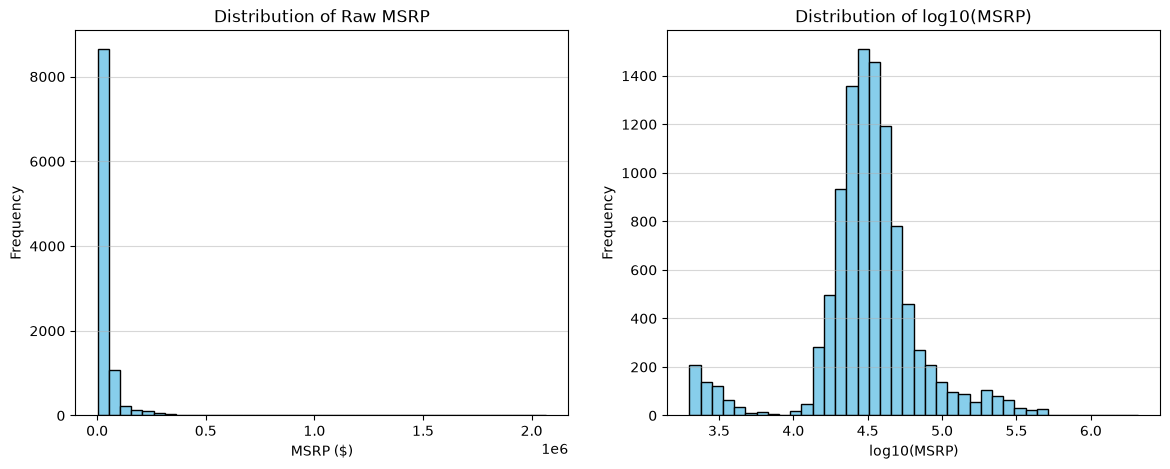

In [167]:
# a) mean and median
# mean is bigger b/c outliers
print(clean["msrp"].agg(["mean", "median"]))

# b) two histograms side by side (plt.subplots(1, 2))
msrp_clean = clean["msrp"].dropna()
msrp_clean = msrp_clean[msrp_clean > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(msrp_clean, bins=40, color="skyblue", edgecolor="black")
axes[0].set_title("Distribution of Raw MSRP")
axes[0].set_xlabel("MSRP ($)")
axes[0].set_ylabel("Frequency")
axes[0].grid(axis="y", alpha=0.5)

log_msrp = np.log10(msrp_clean)
axes[1].hist(log_msrp, bins=40, color="skyblue", edgecolor="black")
axes[1].set_title("Distribution of log10(MSRP)")
axes[1].set_xlabel("log10(MSRP)")
axes[1].set_ylabel("Frequency")
axes[1].grid(axis="y", alpha=0.5)


# c) share of cars above the mean
mean_val = clean["msrp"].mean()
percentage_above_mean = (len(clean[clean["msrp"] > mean_val]) / len(clean)) * 100
print(f"{percentage_above_mean:.2f}%")

**Answer:** Use the median because there are a lot of cars above the average skewing the data.

### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [154]:
# a) mean and std of highway_mpg by vehicle_size, 2017 only
clean_2017 = clean[clean["year"] == 2017]

df_2017 = clean_2017.groupby("vehicle_size")["highway_mpg"].agg(["mean", "std"])

print(stats)

# b) z = (value - class mean) / class std
civic_mpg = 42.0 
volvo_mpg = 34.0 

compact_mean = df_2017.loc["Compact", "mean"]
compact_std = df_2017.loc["Compact", "std"]

large_mean = df_2017.loc["Large", "mean"]
large_std = df_2017.loc["Large", "std"]

z_civic = (civic_mpg - compact_mean) / compact_std 
z_volvo = (volvo_mpg - large_mean) / large_std

print(f"Z score of civic: {z_civic}")
print(f"Z socre of volvo: {z_volvo}")

<module 'scipy.stats' from '/usr/local/python/3.14.2/lib/python3.14/site-packages/scipy/stats/__init__.py'>
Z score of civic: 1.700193024207198
Z socre of volvo: 3.1563761435421007


**Answer:** The volvo is more impressive because compared to its class of large cars it is more unnatural than the civic because its car class on average also has a lot of mpg.

---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

a) 2017 Actual Median MSRP: $36675.0


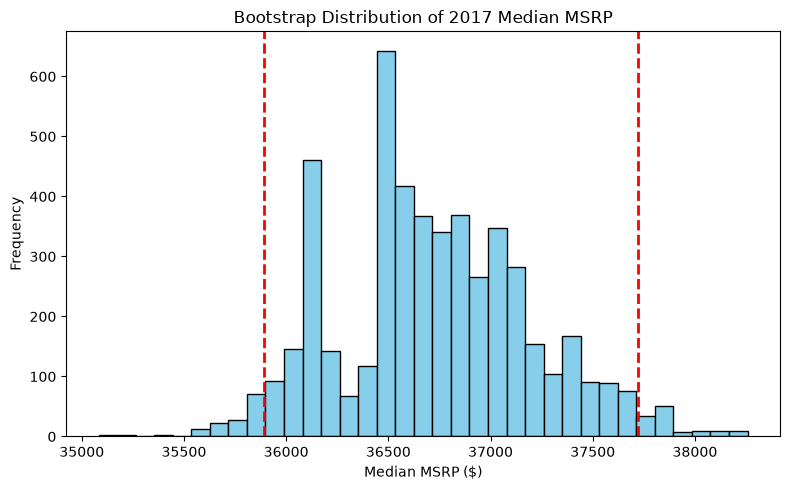

c) 2017 Subaru Actual Median MSRP: $25820.0


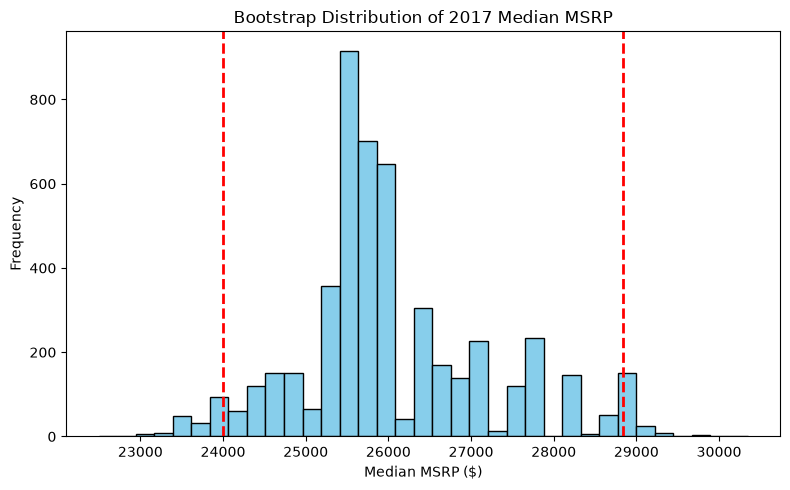

In [ ]:
def bootstrap_median(values, n_boot=5000):
    """Return an array of n_boot bootstrap medians."""
    # hint: rng.choice(values, size=len(values), replace=True)
    medians = np.zeros(n_boot)

    for i in range(n_boot):
        data_sample = rng.choice(values, size=len(values), replace=True) 
        medians[i] = np.median(data_sample)
    
    return medians

# a, b)
cleaned_2017 = clean[clean["year"] == 2017]
msrp_2017 = cleaned_2017["msrp"].dropna().values

ci_lower = np.percentile(bootstrap, 2.5)
ci_upper = np.percentile(bootstrap, 97.5)

actual_median = np.median(msrp_2017)
print(f"a) 2017 Actual Median MSRP: ${actual_median}")

bootstrap = bootstrap_median(msrp_2017) 

plt.figure(figsize=(8, 5))
plt.hist(bootstrap, bins=35, color="skyblue", edgecolor="black")
plt.axvline(ci_lower, color="red", linestyle="--", linewidth=2, label="95% CI Bounds")
plt.axvline(ci_upper, color="red", linestyle="--", linewidth=2)
plt.title("Bootstrap Distribution of 2017 Median MSRP")
plt.xlabel("Median MSRP ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# c)
clean[clean["year"] == 2017]["make"].value_counts()

subaru_2017 = cleaned_2017[cleaned_2017["make"] == "Subaru"]
subaru_msrp = subaru_2017["msrp"].dropna().values

subaru_median_2017 = np.median(subaru_msrp)
print(f"c) 2017 Subaru Actual Median MSRP: ${subaru_median_2017}")

bootstrap_subaru = bootstrap_median(subaru_msrp) 
subaru_ci_lower = np.percentile(bootstrap_subaru, 2.5)
subaru_ci_upper = np.percentile(bootstrap_subaru, 97.5)

plt.figure(figsize=(8, 5))
plt.hist(bootstrap_subaru, bins=35, color="skyblue", edgecolor="black")
plt.axvline(subaru_ci_lower, color="red", linestyle="--", linewidth=2, label="95% CI Bounds")
plt.axvline(subaru_ci_upper, color="red", linestyle="--", linewidth=2)
plt.title("Bootstrap Distribution of 2017 Median MSRP")
plt.xlabel("Median MSRP ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Shoutout gemini for the plots

**Answer:** The 2017 subaru's values are wider because there are only 46 data points for it so the other one follows more of a normal distribution whereas the 2017 one has a large peak at around the 25000 range.

D.) The plot shows that we can be 95% confident that the true median for all 2017 cars is between those two red lines. ($35890.0 - $37720.0)

---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

Compact 2017 Cars: 506
30.99604743083004


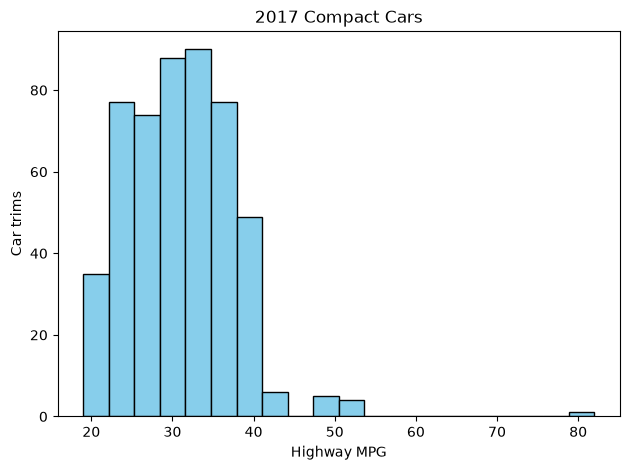

P: 0.00029102460816395184
make        model          
Acura       ILX                 6
            NSX                 1
Audi        A3                 12
            Q3                  6
            R8                  2
                               ..
Volkswagen  Golf Alltrack       5
            Golf GTI           10
            Golf R              4
            Golf SportWagen     4
            Tiguan              8
Name: count, Length: 86, dtype: int64
P trim 0.005430814011009167


In [166]:
# b) sample: 2017 compact cars (MPG you trust); n, mean, histogram
compact_2017 = cleaned_2017[cleaned_2017["vehicle_size"] == "Compact"].copy()
print(f"Compact 2017 Cars: {len(compact_2017)}")

compact_mpg = compact_2017["highway_mpg"].dropna().values

print(compact_mpg.mean())

plt.hist(compact_mpg, bins=20, color="skyblue", edgecolor="black")
plt.title("2017 Compact Cars")
plt.xlabel("Highway MPG")
plt.ylabel("Car trims")
plt.tight_layout()
plt.show()

# c) one-sample t-test vs 30
t_raw, p_raw = stats.ttest_1samp(compact_mpg, popmean=30, alternative="greater")
print(f"P: {p_raw}")

# d) rows per make+model, then one row per model and retest
model_make_group = compact_2017.groupby(["make", "model"])

print(model_make_group["make"].value_counts())

model_avg_mpg = model_make_group["highway_mpg"].mean().dropna()
t, p = stats.ttest_1samp(model_avg_mpg, popmean=30, alternative="greater")
print(f"P trim {p}")

**Answer:** a.) Ho: The average is 30 or less; Ha: the average is strictly greater than 30. We want to know if the value moved in one direction so we use a one sided test here. I would trust the trimmed p value based on group of makes and models b/c then individual trims have less weight so it represents the data better. Marketing can probably safely say the 30mpg claim, though this is not taking into account city mpg and how the cars perform in heavy traffic. 

### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

In [ ]:
# a) compare median MSRP by transmission type
manual = clean[clean["transmission_type"] == "MANUAL"]
automatic = clean[clean["transmission_type"] == "AUTOMATIC"]

print(f"Manual Median: {manual['msrp'].median()}")
print(f"Automatic Median: {automatic['msrp'].median()}")

# b) compare year by transmission type
print(f"Manual Median Year: {manual["year"].median()}")
print(f"Automatic Median Year: {automatic["year"].median()}")

# Median year for manuals are much lower than automatics

# c) compare 2015-2017 medians overall and within each vehicle_size
# For 2015-17 compacts, test automatic vs manual prices with:
# stats.mannwhitneyu(auto, manual)
recent_cars = clean[clean["year"].between(2015, 2017)]

print(recent_cars.groupby("transmission_type")["msrp"].median())

print(recent_cars.groupby(["vehicle_size", "transmission_type"])["msrp"].median())

recent_compacts = recent_cars[recent_cars["vehicle_size"] == "Compact"]
auto_prices = recent_compacts[recent_compacts["transmission_type"] == "AUTOMATIC"]["msrp"].dropna()
manual_prices = recent_compacts[recent_compacts["transmission_type"] == "MANUAL"]["msrp"].dropna()

stat, p = stats.mannwhitneyu(auto_prices, manual_prices)
print(f"Mann who is this white guy test: {p}")

Manual Median: 21810.0
Automatic Median: 33625.0
Manual Median Year: 2008.0
Automatic Median Year: 2015.0
transmission_type
AUTOMATED_MANUAL    41125.0
AUTOMATIC           37037.5
DIRECT_DRIVE        39900.0
MANUAL              26905.0
Name: msrp, dtype: float64
vehicle_size  transmission_type
Compact       AUTOMATED_MANUAL      36097.5
              AUTOMATIC             25995.0
              DIRECT_DRIVE          41450.0
              MANUAL                25860.0
Large         AUTOMATED_MANUAL     105850.0
              AUTOMATIC             44410.0
              MANUAL                38395.0
Midsize       AUTOMATED_MANUAL      49000.0
              AUTOMATIC             37962.5
              DIRECT_DRIVE          27822.5
              MANUAL                26920.0
Name: msrp, dtype: float64
Mann who is this white guy test: 0.1990381369881946


**Answer:** Manual cars are only cheaper considering a lot of them are older models. If we consider for newer cars it is just as expensive and the high p value supports this conclusion. So chill out sales reps and sell whatever the customer wants.

### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [210]:
# a) Welch t-test, 4-door vs 2-door
four_door = clean[clean["number_of_doors"] == 4.0]["highway_mpg"].dropna().values
two_door = clean[clean["number_of_doors"] == 2.0]["highway_mpg"].dropna().values

four_mean = four_door.mean()
two_mean = two_door.mean()

t, p = stats.ttest_ind(four_door, two_door, equal_var=False)
print(f"Mean difference {four_mean - two_mean}")
print(f"P val: {p}")

# b) yearly gas cost = miles * price_per_gallon / mpg
miles_per_year = 12000 
price_per_gallon = 3.50

four_cost = (12000 * price_per_gallon) / (four_mean)
two_cost = (12000 * price_per_gallon) / (two_mean) 

saved = two_cost - four_cost

print(f"Yearly savings by riding 2 door ${saved:.2f}")

# c) simulation
n_sims, hits = 1000, 0
for _ in range(n_sims):
    four_sample = rng.choice(four_door, 30, replace=False) 
    two_sample = rng.choice(two_door, 30, replace=False)

    t, p = stats.ttest_ind(four_sample, two_sample, equal_var=False) 
    if p < 0.05:
        hits += 1

percentage = (hits / n_sims) * 100
print(f"Fraction of tests sig {percentage:.2f}%")

Mean difference 1.5750421905193512
P val: 4.276548560051863e-33
Yearly savings by riding 2 door $97.60
Fraction of tests sig 15.60%


In [211]:
clean[clean["make"] == "Audi"]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
17,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Midsize,Sedan,24,17,3105,NaN
19,Audi,100,1992,regular unleaded,172.0,6.0,AUTOMATIC,all wheel drive,4.0,Midsize,Wagon,20,16,3105,NaN
21,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,all wheel drive,4.0,Midsize,Sedan,21,16,3105,NaN
22,Audi,100,1993,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Midsize,Sedan,24,17,3105,NaN
23,Audi,100,1993,regular unleaded,172.0,6.0,AUTOMATIC,all wheel drive,4.0,Midsize,Wagon,20,16,3105,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10901,Audi,TTS,2016,premium unleaded (required),292.0,4.0,AUTOMATED_MANUAL,all wheel drive,2.0,Compact,Coupe,27,23,3105,51900.0
10902,Audi,TTS,2017,premium unleaded (required),292.0,4.0,AUTOMATED_MANUAL,all wheel drive,2.0,Compact,Coupe,27,23,3105,52500.0
11178,Audi,V8,1992,regular unleaded,276.0,8.0,AUTOMATIC,all wheel drive,4.0,Midsize,Sedan,18,13,3105,NaN
11179,Audi,V8,1993,regular unleaded,276.0,8.0,AUTOMATIC,all wheel drive,4.0,Midsize,Sedan,18,13,3105,2149.0


**Answer:**

---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

**Memo:** Yo hiring manager ngl loved the dataset but I need to get paid more for this. Manual cars lowkey cost less if you are just viewing the raw data and comparing the medians/means. However manager if u a smart data scientist fr you would notice that most of the manual cars are actually older models which skews the manuals to be cheaper. When we isolate to just newer models (2015-2017) it was not exactly true that manuals were in fact cheaper as the manuals and automatics were around the same median/mean. It all depends on how you see the data, manager. Also on that note manager our sales reps can now say our compact cars average 30 mph. But fr kinda a scam because if we consider city mpg probably a lot less. In the best case scenario tho ig our customers would get 30mph on the highway with no traffic so whatever sells ig. But manager this dataset was kinda limited ngl cuz every individual trim was treated as a seperate dataset. Like an Audi 1992 with 172 engine hp counts as like 3 seperate datapoints b/c one is manual one is all wheel drive, etc. To get more accurate results the data should be more uniform (one trim counts for one car...). Please give raise for this work I am a starving CS major!

---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

In [159]:
# S1

### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [160]:
# S2